<a href="https://colab.research.google.com/github/AliShahroor/HBKU-Assignment/blob/main/python-basics/google-colab-r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
install.packages("C50")
install.packages("gmodels")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [23]:
require(C50)
require(gmodels)

In [3]:
dataset = read.csv("iris.csv", header = TRUE, stringsAsFactors = FALSE)
head(dataset)

,sepal.length,sepal.width,petal.length,petal.width,variety
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,5.1,3.5,1.4,0.2,Setosa
2,4.9,3.0,1.4,0.2,Setosa
3,4.7,3.2,1.3,0.2,Setosa
4,4.6,3.1,1.5,0.2,Setosa
5,5.0,3.6,1.4,0.2,Setosa
6,5.4,3.9,1.7,0.4,Setosa


In [5]:
str(dataset)

'data.frame':	150 obs. of  5 variables:
 $ sepal.length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ sepal.width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ petal.length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ petal.width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ variety     : chr  "Setosa" "Setosa" "Setosa" "Setosa" ...


In [25]:
set.seed(123)

dataset <- dataset[sample(nrow(dataset)), ]
head(dataset)

,sepal.length,sepal.width,petal.length,petal.width,variety
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
26,5.0,3.0,1.6,0.2,Setosa
114,5.7,2.5,5.0,2.0,Virginica
111,6.5,3.2,5.1,2.0,Virginica
130,7.2,3.0,5.8,1.6,Virginica
141,6.7,3.1,5.6,2.4,Virginica
131,7.4,2.8,6.1,1.9,Virginica


In [26]:
train_size <- floor(0.7 * nrow(dataset))

train_data <- dataset[1: train_size, ]

test_data <- dataset[(train_size + 1):nrow(dataset), ]

print(paste("Total rows:", nrow(dataset)))
print(paste("Training set size:", nrow(train_data), "(70%)"))
print(paste("Testing set size:", nrow(test_data), "(30%)"))

[1] "Total rows: 150"
[1] "Training set size: 105 (70%)"
[1] "Testing set size: 45 (30%)"


In [27]:
train_data$variety <- as.factor(train_data$variety)
test_data$variety <- as.factor(test_data$variety)

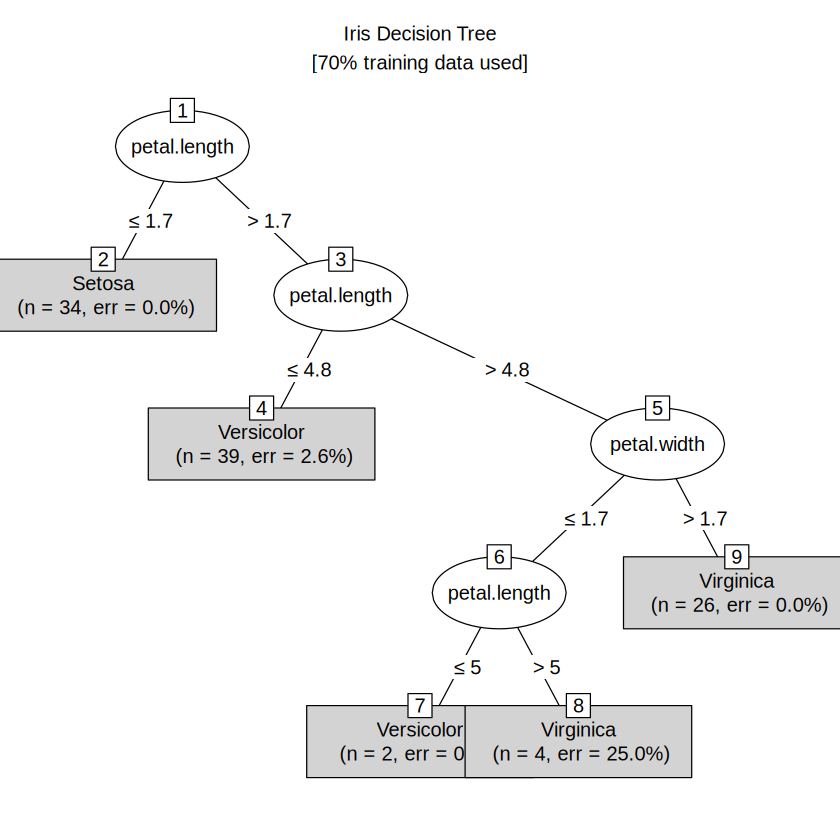

In [28]:
model <- C5.0(train_data[, -5], train_data[, 5])
plot(model, type = "s", main = "Iris Decision Tree\n[70% training data used]")

In [30]:
predictions <- predict(model, test_data[, -5])

In [31]:
confusion_matrix <- table(Actual = test_data$variety, Predicted = predictions)
print(confusion_matrix)

            Predicted
Actual       Setosa Versicolor Virginica
  Setosa         14          2         0
  Versicolor      0          9         0
  Virginica       0          3        17


In [32]:
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
print(paste("Test Set Accuracy:",round(accuracy * 100, 2),"%"))


errors <- sum(confusion_matrix) - sum(diag(confusion_matrix))

print(paste("Number of Incorrect Predictions:", errors))

[1] "Test Set Accuracy: 88.89 %"
[1] "Number of Incorrect Predictions: 5"
